# Gaussian Process Regression from Scratch for Battery State-of-Health (SOH) Prediction

This notebook presents a comprehensive implementation of **Gaussian Process Regression (GPR) from scratch** (using only NumPy, Pandas, and Matplotlib) to estimate the State-of-Health (SOH) of Li-ion batteries based on NASA aging datasets. We implement the kernels, Cholesky solver, predictive inference, and baseline models completely from scratch.


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Vectorized Cholesky Solver from Scratch
def cholesky_scratch(A):
    N = A.shape[0]
    L = np.zeros((N, N))
    for j in range(N):
        val = A[j, j] - np.sum(L[j, :j]**2)
        if val <= 0:
            val = 1e-12
        L[j, j] = np.sqrt(val)
        if j < N - 1:
            L[j+1:, j] = (A[j+1:, j] - np.dot(L[j+1:, :j], L[j, :j])) / L[j, j]
    return L


## 2. Dataset Ingestion and Structure Inspection

We load the raw MATLAB `.mat` data structure for battery unit **B0005** to inspect its layout.


In [39]:
mat = loadmat("Battery_DataSet/B0005.mat")
print(mat.keys())


dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


In [40]:
battery = mat["B0005"]
cycles = battery[0,0]["cycle"][0]
print("Data Type:", type(battery))
print("Shape:", battery.shape)
print("Fields in battery struct:", battery[0,0].dtype.names)
print("Number of cycles in dataset:", len(cycles))


Data Type: <class 'numpy.ndarray'>
Shape: (1, 1)
Fields in battery struct: ('cycle',)
Number of cycles in dataset: 616


In [41]:
capacity_data = []
cycle_num = 1
for cycle in cycles:
    if cycle["type"][0] == "discharge":
        capacity = cycle["data"][0,0]["Capacity"][0,0]
        capacity_data.append([cycle_num, capacity])
        cycle_num += 1


In [42]:
df = pd.DataFrame(capacity_data, columns=["Cycle", "Capacity"])
df.to_csv("B0005_SOH.csv", index=False)
print(df.head())


   Cycle  Capacity
0      1  1.856487
1      2  1.846327
2      3  1.835349
3      4  1.835263
4      5  1.834646


### 2.1 SOH Calculation and Feature Engineering

The State of Health (SOH) is calculated as the ratio of current capacity to the initial nominal capacity.


In [43]:
initial_capacity = df["Capacity"].iloc[0]
df["SOH"] = df["Capacity"] / initial_capacity
print(df.head())


   Cycle  Capacity       SOH
0      1  1.856487  1.000000
1      2  1.846327  0.994527
2      3  1.835349  0.988614
3      4  1.835263  0.988567
4      5  1.834646  0.988235


### 2.2 Visualizing SOH Degradation Curve

We plot the SOH degradation over cycle numbers.


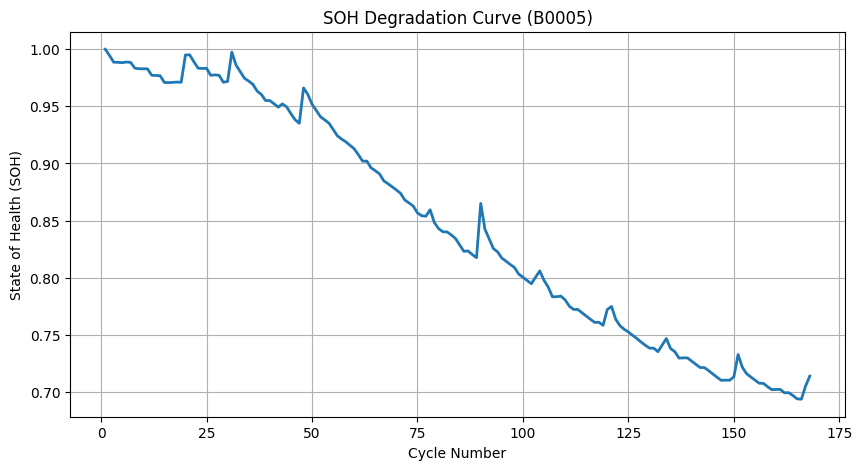

In [44]:
plt.figure(figsize=(10,5))
plt.plot(df["Cycle"], df["SOH"], linewidth=2)
plt.xlabel("Cycle Number")
plt.ylabel("State of Health (SOH)")
plt.title("SOH Degradation Curve (B0005)")
plt.grid(True)
plt.show()


### 2.3 Reshaping Features and Targets for GPR


In [45]:
X = df["Cycle"].values.reshape(-1,1)
y = df["SOH"].values


### 2.4 Chronological Train-Test Split (70/30)


In [46]:
split_idx = int(0.7 * len(X))
X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]


In [47]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (117, 1)
Test size: (51, 1)


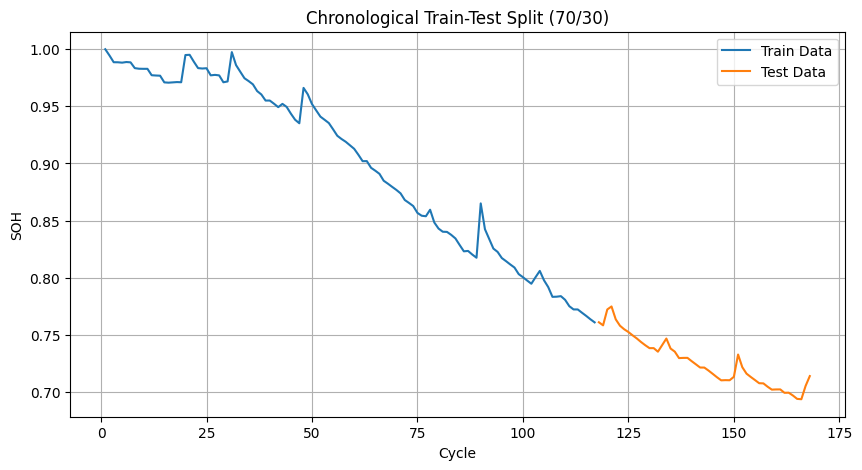

In [48]:
plt.figure(figsize=(10,5))
plt.plot(X_train, y_train, label="Train Data")
plt.plot(X_test, y_test, label="Test Data")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Chronological Train-Test Split (70/30)")
plt.legend()
plt.grid(True)
plt.show()


### 2.6 Calculating Observation Noise Variance from Dataset

Following standard regression methodology, we estimate the observation noise variance ($\sigma_n^2$) by fitting a linear degradation trend to the training SOH data and calculating the variance of the residuals.


In [49]:
# Fit a linear trend to the training dataset SOH to estimate noise residuals
p = np.polyfit(X_train.flatten(), y_train, 1)
y_trend = np.polyval(p, X_train.flatten())
noise = np.var(y_train - y_trend)
print("Calculated Noise Variance (sigma_n^2):", noise)


Calculated Noise Variance (sigma_n^2): 0.00028668131319509665


## 3. GPR Implementation with Squared Exponential (RBF) Kernel

We implement the RBF kernel and fit the GP model using a Cholesky solver from scratch.


In [50]:
def rbf_kernel(X1, X2, length_scale=100, sigma_f=1.0):
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return sigma_f**2 * np.exp(-0.5 * sqdist / length_scale**2)


In [51]:
K = rbf_kernel(X_train, X_train) + noise * np.eye(len(X_train))
K_s = rbf_kernel(X_train, X_test)
K_ss = rbf_kernel(X_test, X_test)


In [52]:
y_train_mean = np.mean(y_train)
y_train_centered = y_train - y_train_mean
L = cholesky_scratch(K)
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train_centered))


In [53]:
posterior_mean = (K_s.T @ alpha) + y_train_mean
v = np.linalg.solve(L, K_s)
posterior_cov = K_ss - v.T @ v
posterior_variance = np.diag(posterior_cov)
posterior_std = np.sqrt(posterior_variance)
lower = posterior_mean - 1.96 * posterior_std
upper = posterior_mean + 1.96 * posterior_std


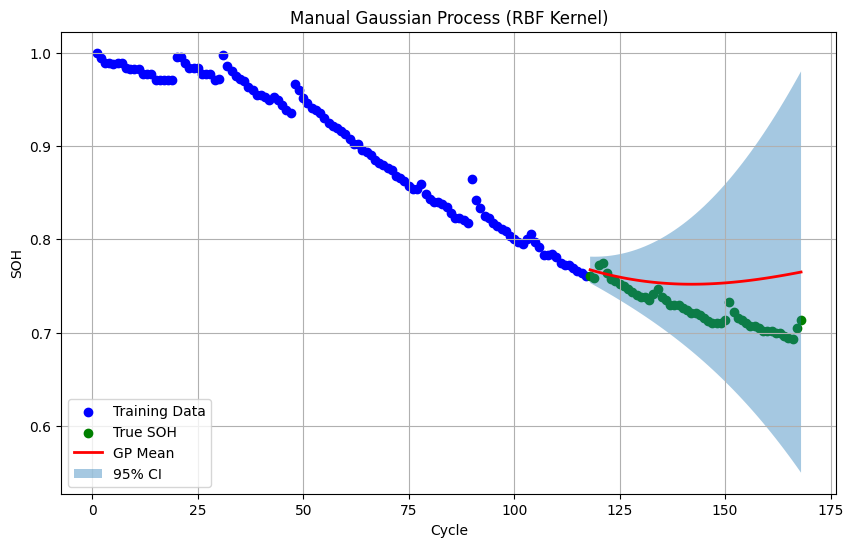

In [54]:
plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, color="blue", label="Training Data")
plt.scatter(X_test, y_test, color="green", label="True SOH")
plt.plot(X_test, posterior_mean, color="red", linewidth=2, label="GP Mean")
plt.fill_between(X_test.flatten(), lower, upper, alpha=0.4, label="95% CI")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Manual Gaussian Process (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


### 3.4 Quantifying Prediction Performance (RMSE, MAE, R²)


In [55]:
rmse = np.sqrt(np.mean((y_test - posterior_mean)**2))
mae = np.mean(np.abs(y_test - posterior_mean))
ss_res = np.sum((y_test - posterior_mean)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - ss_res / ss_tot
print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)


RMSE = 0.03701424298510298
MAE = 0.03136027841334203
R2 = -2.00655509916856


### 3.5 Calculating Negative Log Likelihood (NLL) from Scratch

We calculate the predictive NLL under the Gaussian predictive distribution.


In [56]:
variance = posterior_variance
variance = np.clip(variance, 1e-12, None)
log_pdf = -0.5 * np.log(2 * np.pi * variance) - ((y_test - posterior_mean)**2) / (2 * variance)
nll = -np.mean(log_pdf)
print("NLL =", nll)


NLL = -2.1732954881632414


## 4. Extrapolative SOH Forecasting (RBF Kernel)


In [57]:
future_cycles = np.arange(X.max()+1, X.max()+201).reshape(-1,1)
K_future = rbf_kernel(X_train, future_cycles)
K_future_future = rbf_kernel(future_cycles, future_cycles)


In [58]:
future_mean = (K_future.T @ alpha) + y_train_mean
v_future = np.linalg.solve(L, K_future)
future_cov = K_future_future - v_future.T @ v_future
future_variance = np.diag(future_cov)
future_std = np.sqrt(future_variance)
future_lower = future_mean - 1.96 * future_std
future_upper = future_mean + 1.96 * future_std


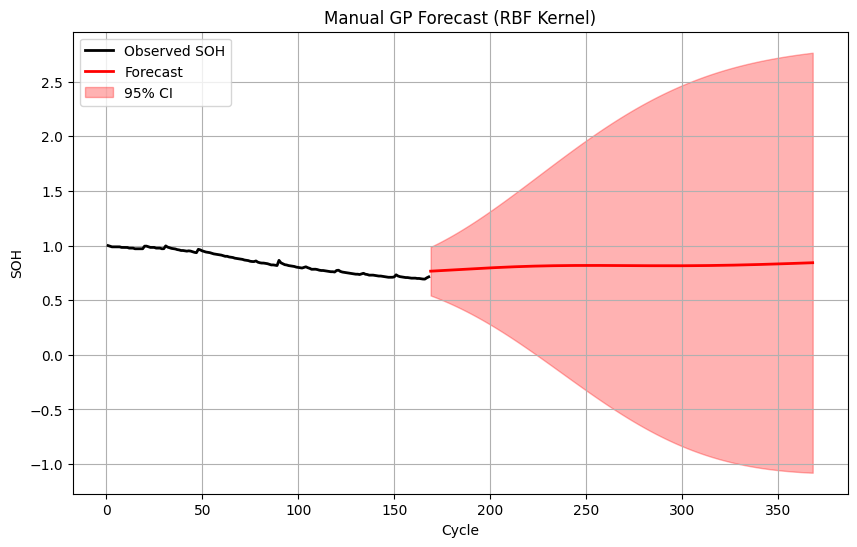

In [59]:
plt.figure(figsize=(10,6))
plt.plot(df["Cycle"], df["SOH"], label="Observed SOH", color="black", linewidth=2)
plt.plot(future_cycles, future_mean, linewidth=2, label="Forecast", color="red")
plt.fill_between(future_cycles.flatten(), future_lower, future_upper, alpha=0.3, label="95% CI", color="red")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Manual GP Forecast (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


## 5. Comparison of Covariance Functions (GPML Chapter 4)

We implement Matern 3/2, Matern 5/2, Rational Quadratic, Linear, and RBF+Linear kernels from scratch.


In [60]:
def matern32_kernel(X1, X2, length_scale=100, sigma_f=1.0):
    dists = np.sqrt(np.sum((X1[:,None]-X2[None,:])**2, axis=2))
    sqrt3 = np.sqrt(3)
    return sigma_f**2 * (1 + sqrt3*dists/length_scale) * np.exp(-sqrt3*dists/length_scale)

def matern52_kernel(X1, X2, length_scale=100, sigma_f=1.0):
    dists = np.sqrt(np.sum((X1[:,None]-X2[None,:])**2, axis=2))
    sqrt5 = np.sqrt(5)
    return sigma_f**2 * (1 + sqrt5*dists/length_scale + 5*dists**2/(3*length_scale**2)) * np.exp(-sqrt5*dists/length_scale)

def rq_kernel(X1, X2, length_scale=100, alpha=1.0, sigma_f=1.0):
    sqdist = np.sum(X1**2,1).reshape(-1,1) + np.sum(X2**2,1) - 2*np.dot(X1,X2.T)
    return sigma_f**2 * (1 + sqdist / (2*alpha*length_scale**2))**(-alpha)

def linear_kernel(X1, X2, sigma_f=1.0):
    return sigma_f**2 * (1.0 + np.dot(X1, X2.T))

def rbf_linear_kernel(X1, X2, length_scale=100, sigma_f=1.0):
    return rbf_kernel(X1, X2, length_scale, sigma_f) + linear_kernel(X1, X2, sigma_f)


In [61]:
kernels = {
    "RBF": rbf_kernel,
    "Matern32": matern32_kernel,
    "Matern52": matern52_kernel,
    "RQ": rq_kernel,
    "Linear": linear_kernel,
    "RBF+Linear": rbf_linear_kernel
}


In [62]:
results = {}
for name, kernel_func in kernels.items():
    K = kernel_func(X_train, X_train) + noise * np.eye(len(X_train))
    K_s = kernel_func(X_train, X_test)
    K_ss = kernel_func(X_test, X_test)
    
    y_train_mean = np.mean(y_train)
    y_train_centered = y_train - y_train_mean
    L = cholesky_scratch(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train_centered))
    
    mean = K_s.T @ alpha + y_train_mean
    v = np.linalg.solve(L, K_s)
    cov = K_ss - v.T @ v
    variance = np.diag(cov)
    
    results[name] = {
        "mean": mean,
        "variance": variance,
        "L": L,
        "alpha": alpha
    }
    print(f"Manual GP with {name} kernel trained.")


Manual GP with RBF kernel trained.
Manual GP with Matern32 kernel trained.
Manual GP with Matern52 kernel trained.
Manual GP with RQ kernel trained.
Manual GP with Linear kernel trained.
Manual GP with RBF+Linear kernel trained.


In [63]:
comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    variance = results[name]["variance"]
    variance = np.clip(variance, 1e-12, None)
    
    rmse = np.sqrt(np.mean((y_test - pred)**2))
    mae = np.mean(np.abs(y_test - pred))
    
    ss_res = np.sum((y_test - pred)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    r2 = 1 - ss_res / ss_tot
    
    log_pdf = -0.5 * np.log(2 * np.pi * variance) - ((y_test - pred)**2) / (2 * variance)
    nll = -np.mean(log_pdf)
    
    comparison.append([name, rmse, mae, r2, nll])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Kernel", "RMSE", "MAE", "R2", "NLL"]
)
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)


       Kernel      RMSE       MAE         R2       NLL
2    Matern52  0.010081  0.008278   0.776997 -1.219370
4      Linear  0.016611  0.012155   0.394471  1.355191
1    Matern32  0.022418  0.017339  -0.102845 -0.641342
5  RBF+Linear  0.031424  0.026950  -1.167041 -2.162582
0         RBF  0.037014  0.031360  -2.006555 -2.173295
3          RQ  0.087043  0.073158 -15.626521 -1.424796


In [64]:
variance_summary = []
for name in results.keys():
    variance = results[name]["variance"]
    variance_summary.append([
        name,
        np.mean(variance),
        np.max(variance),
        variance[-1]
    ])
variance_df = pd.DataFrame(
    variance_summary,
    columns=["Kernel", "Avg Variance", "Max Variance", "Final Variance"]
)
print(variance_df)


       Kernel  Avg Variance  Max Variance  Final Variance
0         RBF      0.002993      0.012047        0.012047
1    Matern32      0.099828      0.281711        0.281711
2    Matern52      0.037810      0.133375        0.133375
3          RQ      0.011341      0.046059        0.046059
4      Linear      0.000018      0.000028        0.000028
5  RBF+Linear      0.003946      0.016684        0.016684


In [65]:
forecast_results = {}
for name, kernel_func in kernels.items():
    K = kernel_func(X_train, X_train) + noise * np.eye(len(X_train))
    K_future = kernel_func(X_train, future_cycles)
    K_future_future = kernel_func(future_cycles, future_cycles)
    
    y_train_mean = np.mean(y_train)
    y_train_centered = y_train - y_train_mean
    L = cholesky_scratch(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train_centered))
    
    mean = K_future.T @ alpha + y_train_mean
    v = np.linalg.solve(L, K_future)
    cov = K_future_future - v.T @ v
    variance = np.diag(cov)
    
    forecast_results[name] = {
        "mean": mean,
        "variance": variance
    }


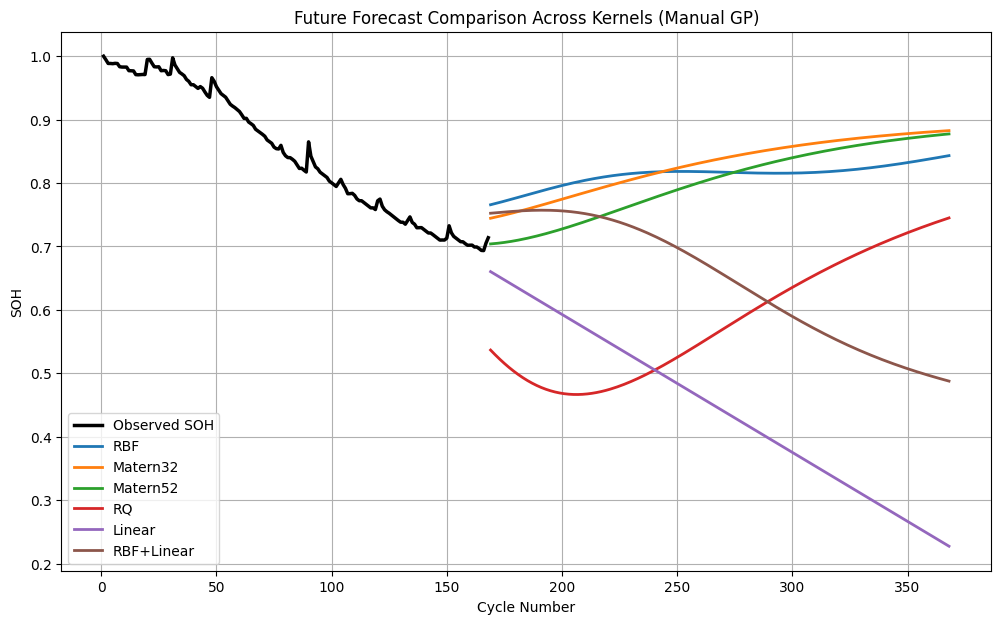

In [66]:
plt.figure(figsize=(12,7))
plt.plot(df["Cycle"], df["SOH"], color="black", linewidth=2.5, label="Observed SOH")
for name in forecast_results.keys():
    plt.plot(future_cycles, forecast_results[name]["mean"], linewidth=2, label=name)
plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Future Forecast Comparison Across Kernels (Manual GP)")
plt.legend()
plt.grid(True)
plt.show()


## 6. Comparison with Baseline Machine Learning Models

We implement Linear Regression, Polynomial Regression (Deg 2), KNN, and Decision Tree regressors entirely from scratch using NumPy.


In [67]:
class LinearRegressionFromScratch:
    def fit(self, X, y):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias @ self.w

class PolynomialRegressionFromScratch:
    def __init__(self, degree=2):
        self.degree = degree
    def fit(self, X, y):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        self.w = np.linalg.solve(X_bias.T @ X_bias + 1e-8 * np.eye(X_bias.shape[1]), X_bias.T @ y)
    def predict(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        X_bias = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])
        return X_bias @ self.w

class KNNRegressorFromScratch:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            idx = np.argsort(dists)[:self.k]
            preds.append(np.mean(self.y_train[idx]))
        return np.array(preds)

class DecisionTreeRegressorFromScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        if depth >= self.max_depth or num_samples < self.min_samples_split or np.std(y) == 0:
            return np.mean(y)
        best_feat, best_thresh, best_mse = None, None, float('inf')
        for feat in range(num_features):
            thresholds = np.unique(X[:, feat])
            if len(thresholds) > 100:
                thresholds = np.percentile(thresholds, np.linspace(0, 100, 50))
            for thresh in thresholds:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if not np.any(left_mask) or not np.any(right_mask):
                    continue
                left_y, right_y = y[left_mask], y[right_mask]
                mse = np.sum((left_y - np.mean(left_y))**2) + np.sum((right_y - np.mean(right_y))**2)
                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat
                    best_thresh = thresh
        if best_feat is None:
            return np.mean(y)
        left_mask = X[:, best_feat] <= best_thresh
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return {"feature": best_feat, "threshold": best_thresh, "left": left_child, "right": right_child}
    def predict(self, X):
        return np.array([self._predict_row(self.tree, row) for row in X])
    def _predict_row(self, node, row):
        if not isinstance(node, dict):
            return node
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_row(node["left"], row)
        else:
            return self._predict_row(node["right"], row)


In [68]:
models_baseline = {
    "Linear Regression": LinearRegressionFromScratch(),
    "Polynomial Regression (Deg 2)": PolynomialRegressionFromScratch(degree=2),
    "K-Nearest Neighbors": KNNRegressorFromScratch(k=5),
    "Decision Tree": DecisionTreeRegressorFromScratch(max_depth=5)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_train, y_train)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained from scratch.")


Baseline 'Linear Regression' trained from scratch.
Baseline 'Polynomial Regression (Deg 2)' trained from scratch.
Baseline 'K-Nearest Neighbors' trained from scratch.
Baseline 'Decision Tree' trained from scratch.


In [69]:
# Implement regression metrics from scratch
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    baseline_results.append([name, rmse, mae, r2, mape])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)


                           Model      RMSE       MAE         R2      MAPE
0              Linear Regression  0.016612  0.012155   0.394415  0.016997
3                  Decision Tree  0.042997  0.038094  -3.056990  0.053286
2            K-Nearest Neighbors  0.045477  0.040704  -3.538513  0.056901
1  Polynomial Regression (Deg 2)  0.089741  0.079783 -16.673283  0.111377


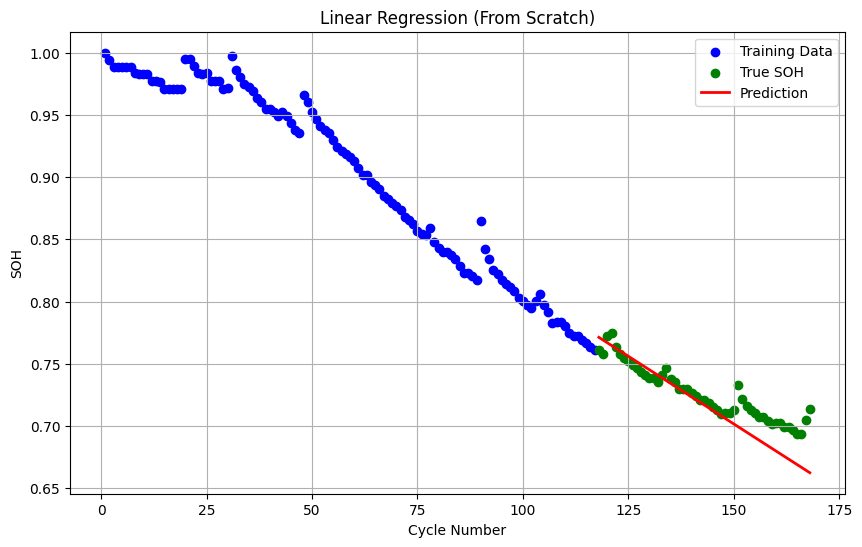

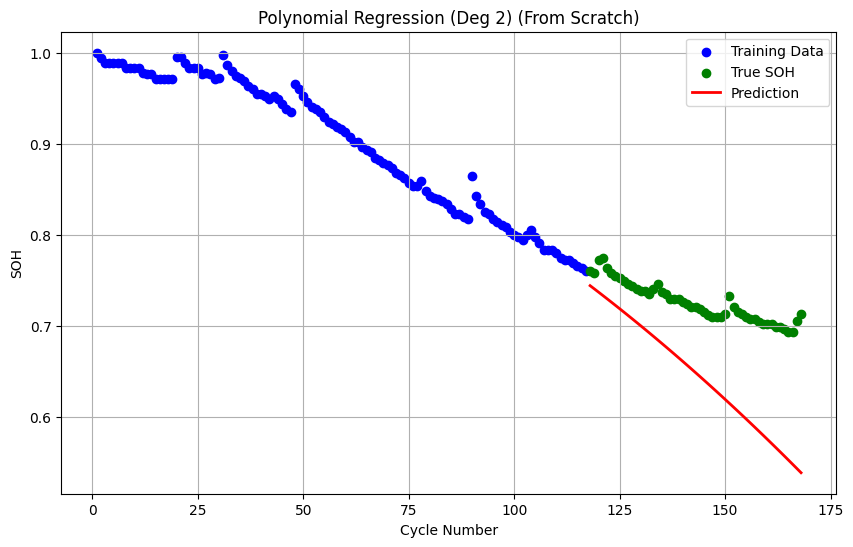

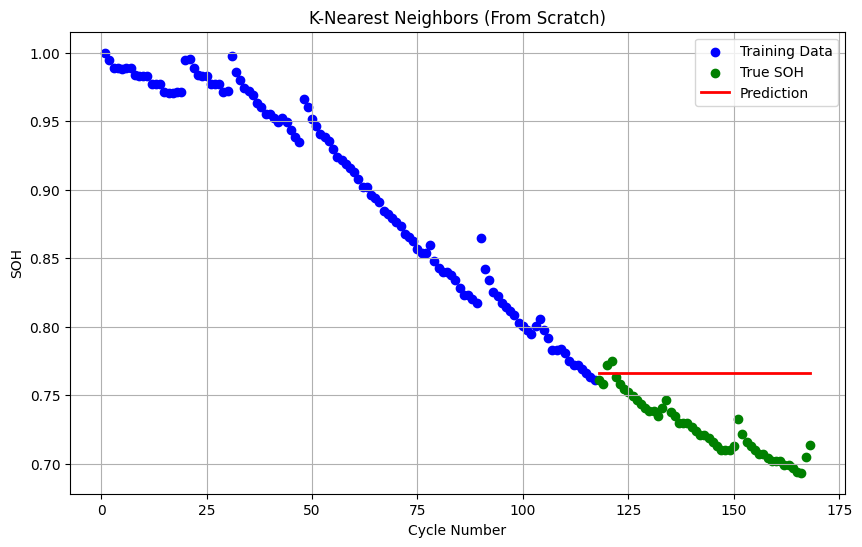

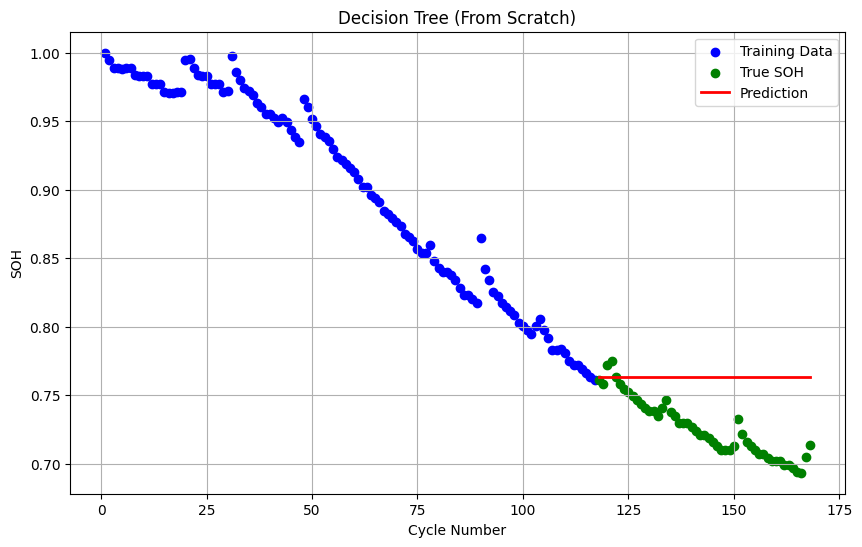

In [70]:
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(10,6))
    plt.scatter(X_train, y_train, color='blue', label='Training Data')
    plt.scatter(X_test, y_test, color='green', label='True SOH')
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Prediction')
    plt.title(f"{name} (From Scratch)")
    plt.xlabel("Cycle Number")
    plt.ylabel("SOH")
    plt.legend()
    plt.grid(True)
    plt.show()


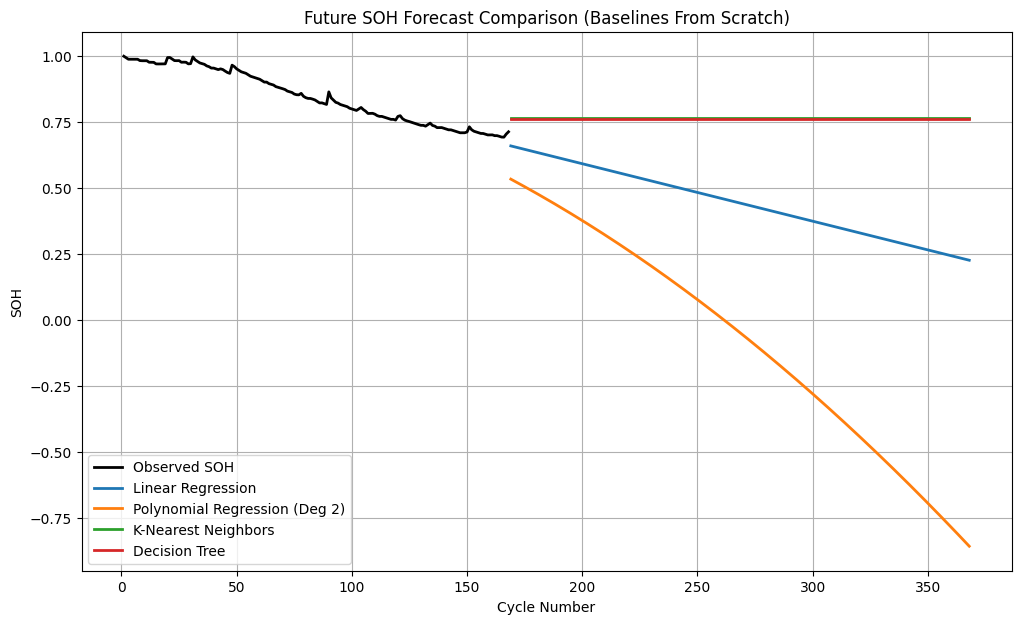

In [71]:
plt.figure(figsize=(12,7))
plt.plot(df["Cycle"], df["SOH"], color='black', linewidth=2, label='Observed SOH')
for name, model in trained_baselines.items():
    future_pred = model.predict(future_cycles)
    plt.plot(future_cycles, future_pred, linewidth=2, label=name)
plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Future SOH Forecast Comparison (Baselines From Scratch)")
plt.legend()
plt.grid(True)
plt.show()


## 7. Summary and Model Ranking

We compile a ranking of all implemented Gaussian Process models and baseline regressors, and visualize their test set root-mean-squared error (RMSE) and accuracy.


In [72]:
joint_results = []

# Add GP kernels
for name in results.keys():
    pred = results[name]["mean"]
    rmse = np.sqrt(np.mean((y_test - pred)**2))
    mape = mean_absolute_percentage_error(y_test, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([f"GPR ({name})", rmse, accuracy])
    
# Add baselines
for name, model in trained_baselines.items():
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([name, rmse, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)


                           Model      RMSE  Accuracy (%)
2                 GPR (Matern52)  0.010081     98.872030
4                   GPR (Linear)  0.016611     98.300362
6              Linear Regression  0.016612     98.300270
1                 GPR (Matern32)  0.022418     97.565889
5               GPR (RBF+Linear)  0.031424     96.223836
0                      GPR (RBF)  0.037014     95.602773
9                  Decision Tree  0.042997     94.671446
8            K-Nearest Neighbors  0.045477     94.309883
3                       GPR (RQ)  0.087043     89.751401
7  Polynomial Regression (Deg 2)  0.089741     88.862254


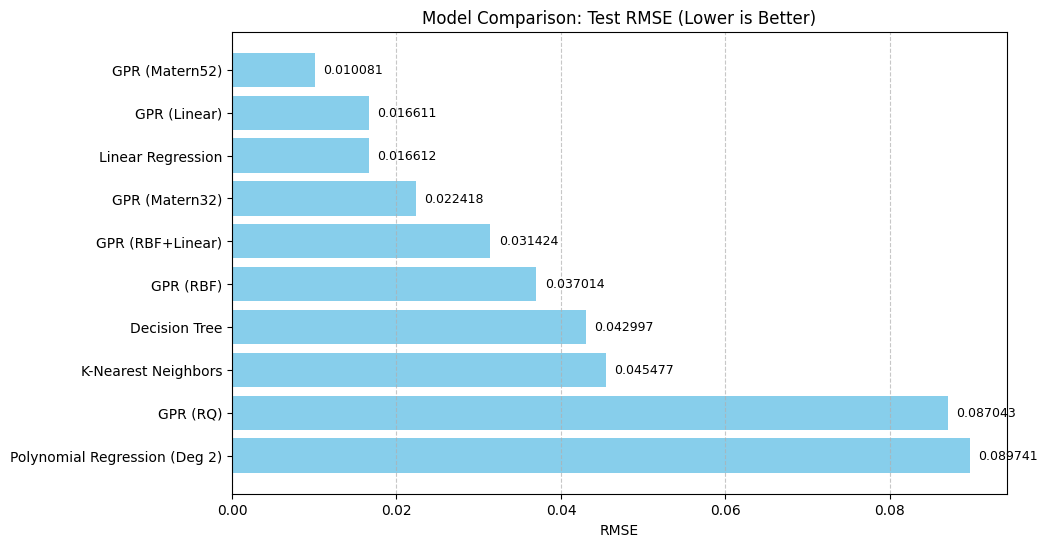

In [73]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f"{width:.6f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


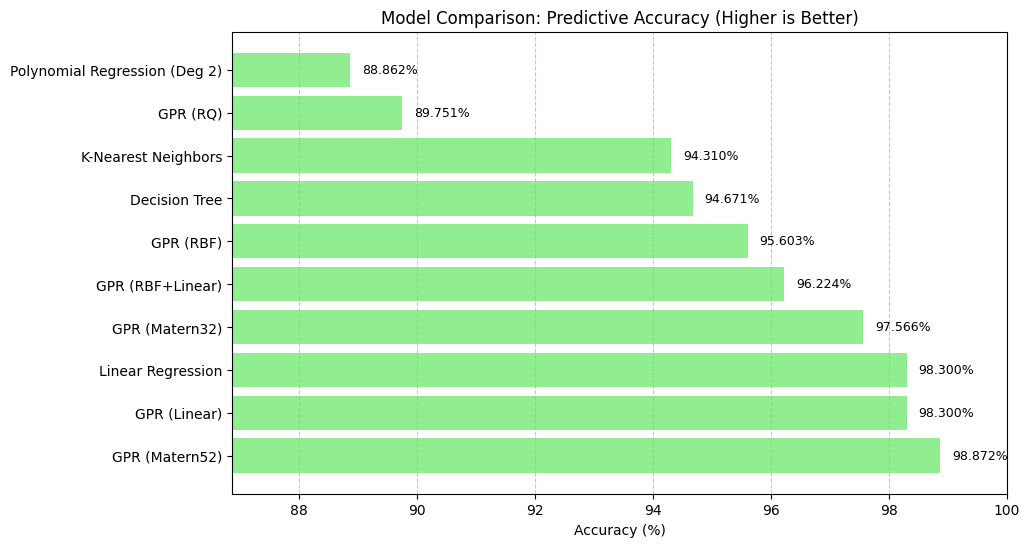

In [74]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
